<a href="https://colab.research.google.com/github/AbdulkaderKharrat/AbdulkaderKharrat/blob/main/chocolate_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Chocolate bar ratings 2022.csv')

In [ ]:
df.head()
# REF : The highest REF numbers were the last entries made
# Company (Manufacturer) : Name of the company
# Company Location : Country of the manufacturing company
# Review Date : The year when the review was conducted to assign the rating
# Country of Bean Origin : Growing country of the beans
# Specific Bean Origin or Bar Name : Name of the chocolate bar or region of origin
# Cocoa Percent : Amount of cocoa used in percent
# Ingredients : Ingredients in the chocolate bar including Beans, Sugar, Cocoa butter, Vanilla, Lecithin, and Salt
# Most Memorable Characteristics	: Reported characteristic of the chocolate bar
# Rating : Rating of the chocolate between 1 and 5

,REF,Company (Manufacturer),Company Location,Review Date,Country of Bean Origin,Specific Bean Origin or Bar Name,Cocoa Percent,Ingredients,Most Memorable Characteristics,Rating
0,2454,5150,U.S.A.,2019,Tanzania,"Kokoa Kamili, batch 1",76%,"3- B,S,C","rich cocoa, fatty, bready",3.25
1,2454,5150,U.S.A.,2019,Madagascar,"Bejofo Estate, batch 1",76%,"3- B,S,C","cocoa, blackberry, full body",3.75
2,2458,5150,U.S.A.,2019,Dominican Republic,"Zorzal, batch 1",76%,"3- B,S,C","cocoa, vegetal, savory",3.50
3,2542,5150,U.S.A.,2021,Fiji,"Matasawalevu, batch 1",68%,"3- B,S,C","chewy, off, rubbery",3.00
4,2542,5150,U.S.A.,2021,India,"Anamalai, batch 1",68%,"3- B,S,C","milk brownie, macadamia,chewy",3.50


In [ ]:
df.describe()

,REF,Review Date,Rating
count,2588.000000,2588.000000,2588.000000
mean,1459.185471,2014.545209,3.198319
std,773.852201,4.082722,0.444069
min,5.000000,2006.000000,1.000000
25%,820.000000,2012.000000,3.000000
50%,1470.000000,2015.000000,3.250000
75%,2122.000000,2018.000000,3.500000
max,2768.000000,2022.000000,4.000000


In [ ]:
df.duplicated().sum()

NameError: name 'df' is not defined

In [ ]:
df.isnull().sum()

,0
REF,0
Company (Manufacturer),0
Company Location,0
Review Date,0
Country of Bean Origin,0
Specific Bean Origin or Bar Name,0
Cocoa Percent,0
Ingredients,87
Most Memorable Characteristics,0
Rating,0


In [ ]:
# Fill NaN values in 'Ingredients' column with the mode
df['Ingredients'] = df['Ingredients'].fillna(df['Ingredients'].mode()[0])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2588 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   REF                               2588 non-null   int64  
 1   Company (Manufacturer)            2588 non-null   object 
 2   Company Location                  2588 non-null   object 
 3   Review Date                       2588 non-null   int64  
 4   Country of Bean Origin            2588 non-null   object 
 5   Specific Bean Origin or Bar Name  2588 non-null   object 
 6   Cocoa Percent                     2588 non-null   object 
 7   Ingredients                       2588 non-null   object 
 8   Most Memorable Characteristics    2588 non-null   object 
 9   Rating                            2588 non-null   float64
dtypes: float64(1), int64(2), object(7)
memory usage: 202.3+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
len(df.Ingredients.unique())

21

In [ ]:
numerical_df = df.select_dtypes(include=['number'])
numerical_df.head()

,REF,Review Date,Rating
0,2454,2019,3.25
1,2454,2019,3.75
2,2458,2019,3.50
3,2542,2021,3.00
4,2542,2021,3.50


In [ ]:
categorical_df = df.select_dtypes(include=['object'])
categorical_df.head()

,Company (Manufacturer),Company Location,Country of Bean Origin,Specific Bean Origin or Bar Name,Cocoa Percent,Ingredients,Most Memorable Characteristics
0,5150,U.S.A.,Tanzania,"Kokoa Kamili, batch 1",76%,"3- B,S,C","rich cocoa, fatty, bready"
1,5150,U.S.A.,Madagascar,"Bejofo Estate, batch 1",76%,"3- B,S,C","cocoa, blackberry, full body"
2,5150,U.S.A.,Dominican Republic,"Zorzal, batch 1",76%,"3- B,S,C","cocoa, vegetal, savory"
3,5150,U.S.A.,Fiji,"Matasawalevu, batch 1",68%,"3- B,S,C","chewy, off, rubbery"
4,5150,U.S.A.,India,"Anamalai, batch 1",68%,"3- B,S,C","milk brownie, macadamia,chewy"


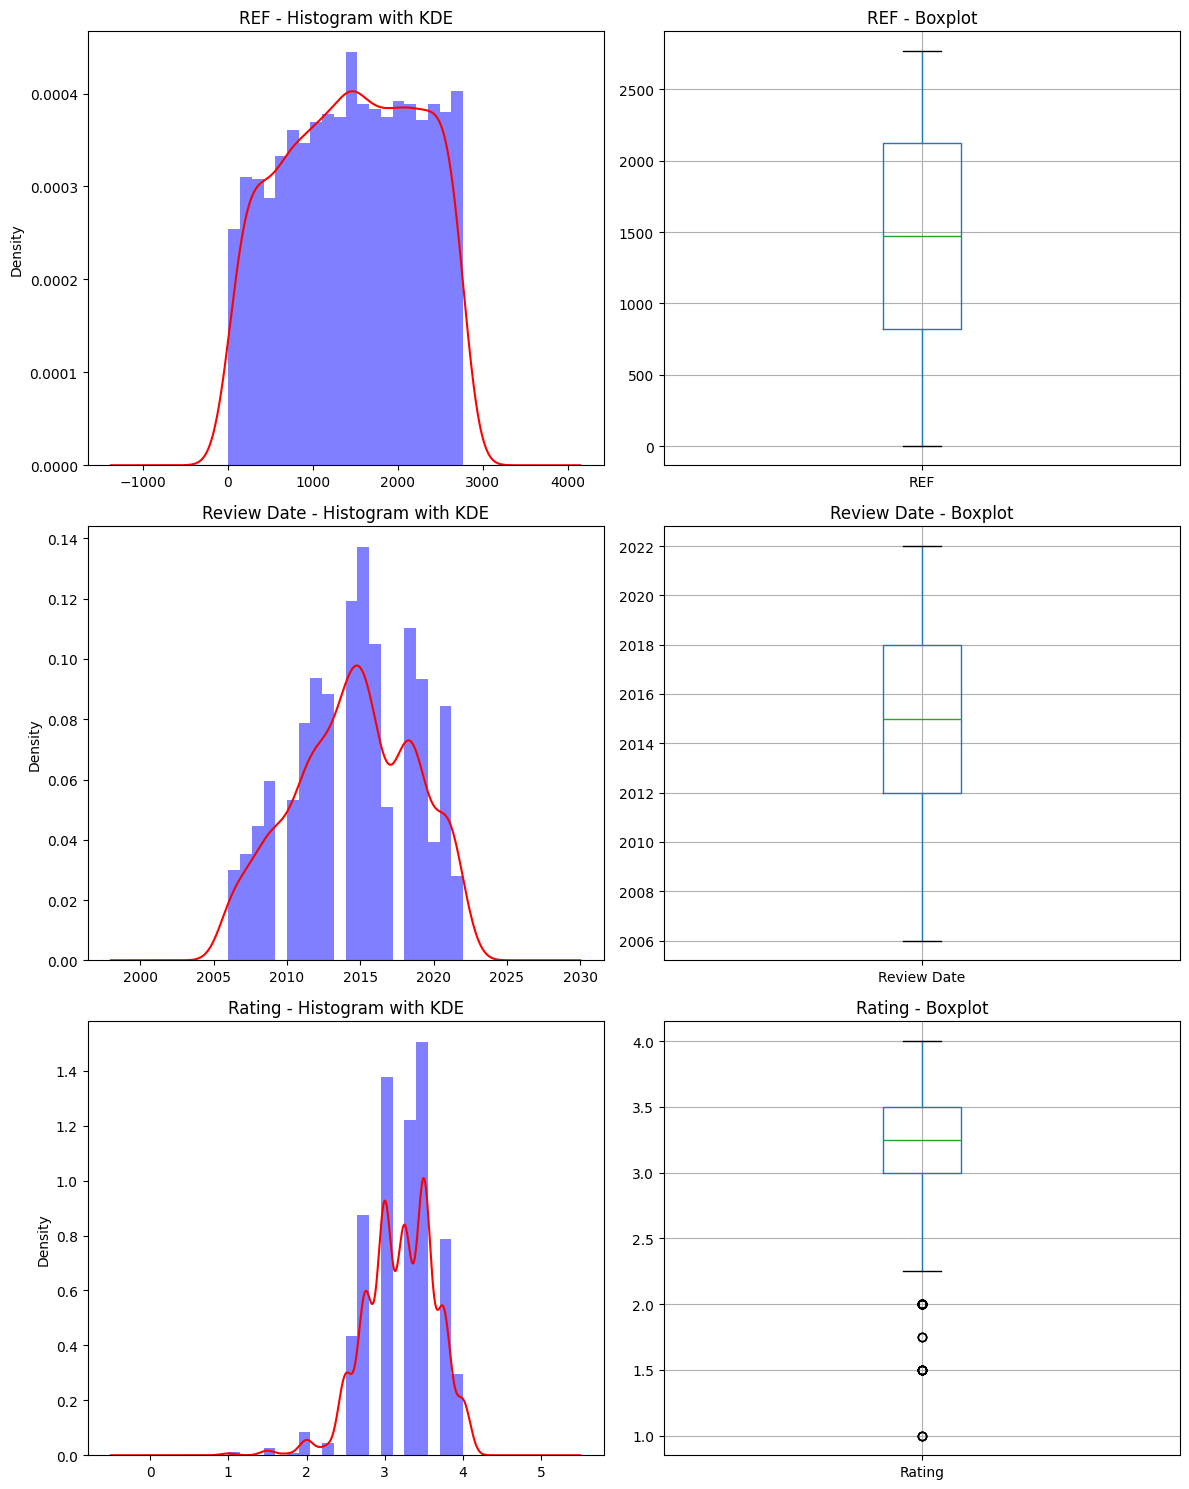

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'numerical_df' from your previous code is the DataFrame
# containing numerical features.  Replace with your actual DataFrame if different.
numerical_features = numerical_df

# Plotting Histogram with KDE and Boxplot for each numerical feature
fig, axes = plt.subplots(len(numerical_features.columns), 2, figsize=(12, 5 * len(numerical_features.columns)))
for i, col in enumerate(numerical_features.columns):
    # Histogram with KDE
    numerical_features[col].plot(kind='hist', density=True, ax=axes[i, 0], bins=20, alpha=0.5, color='blue')
    numerical_features[col].plot(kind='kde', ax=axes[i, 0], color='red')
    axes[i, 0].set_title(f'{col} - Histogram with KDE')
    # Boxplot
    numerical_features.boxplot(column=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Boxplot')
plt.tight_layout()
plt.show()


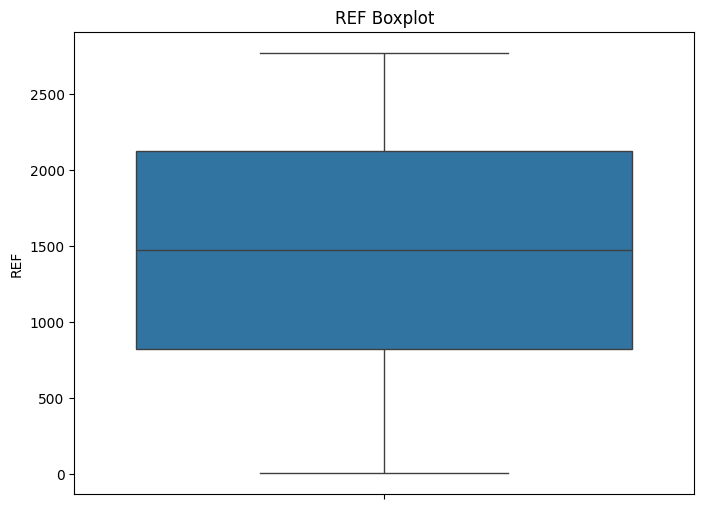

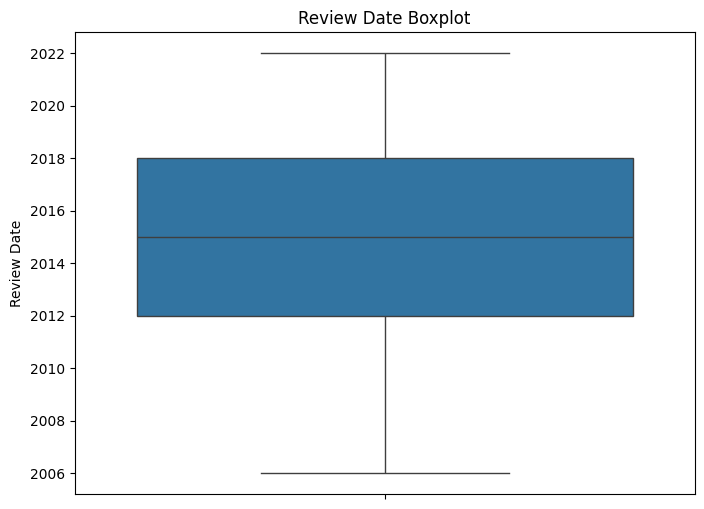

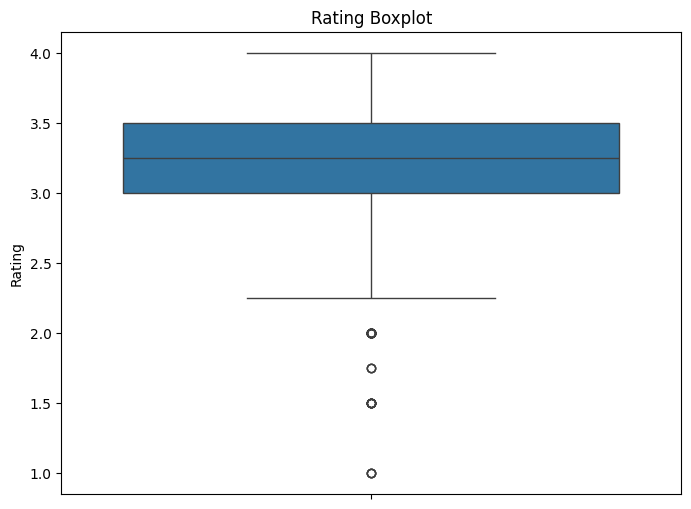

In [ ]:
# prompt: do a boxplot for all coloumns

import matplotlib.pyplot as plt
# Iterate through numerical columns and create boxplots
numerical_cols = df.select_dtypes(include=['number']).columns
for col in numerical_cols:
  plt.figure(figsize=(8, 6))  # Adjust figure size as needed
  sns.boxplot(y=df[col])
  plt.ylabel(col)
  plt.title(f'{col} Boxplot')
  plt.show()


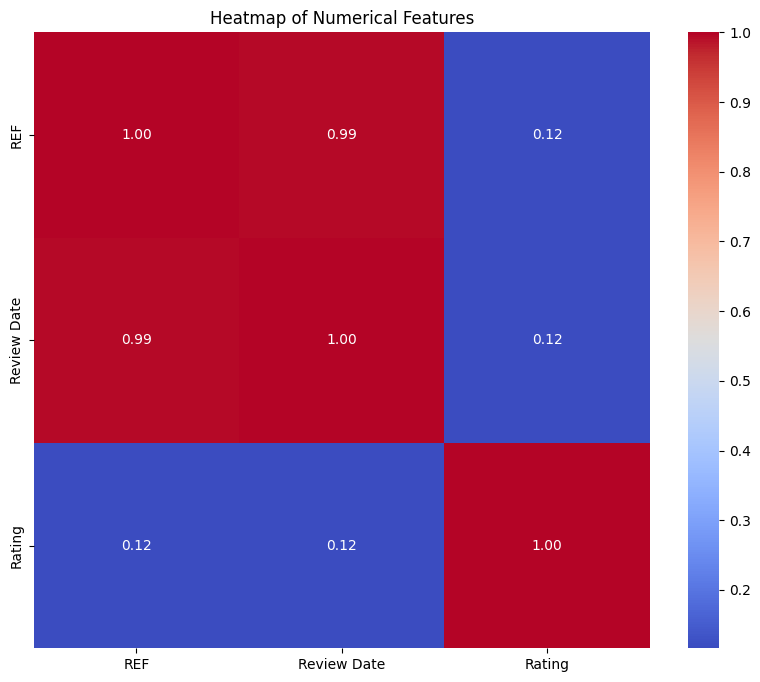

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'numerical_features' is defined as in your previous code
# If not, replace with your actual DataFrame containing numerical features

corr = numerical_features.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Heatmap of Numerical Features')
plt.show()


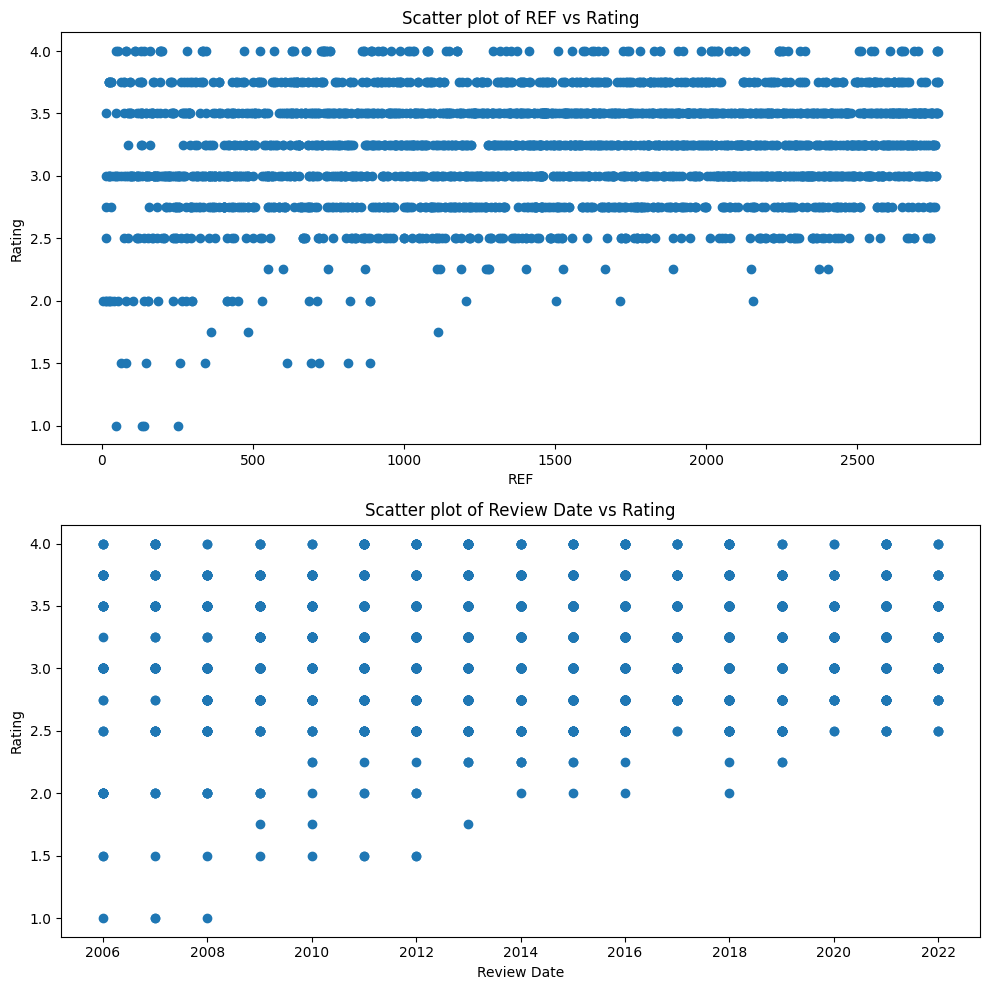

In [ ]:
import matplotlib.pyplot as plt
# Assuming 'numerical_features' is defined as in your previous code
# If not, replace with your actual DataFrame containing numerical features

# scatter
# Creating scatter plots for each feature against the Rating (Assuming 'Rating' is the target variable)
n_features = numerical_features.shape[1] - 1  # excluding the 'Rating' column
if n_features > 0: #check if there are numerical features other than Rating
  fig, axs = plt.subplots(n_features, figsize=(10, n_features * 5))

  # Iterate through columns except the last one ('Rating')
  for i, feature in enumerate(numerical_features.columns[:-1]):
      axs[i].scatter(numerical_features[feature], numerical_features['Rating']) # Use 'Rating' instead of 'price'
      axs[i].set_xlabel(feature)
      axs[i].set_ylabel('Rating') # Use 'Rating' instead of 'Price'
      axs[i].set_title(f'Scatter plot of {feature} vs Rating') # Use 'Rating' instead of 'Price'
  plt.tight_layout()
  plt.show()
else:
  print("No numerical features other than Rating to plot.") # Use 'Rating' instead of 'price'

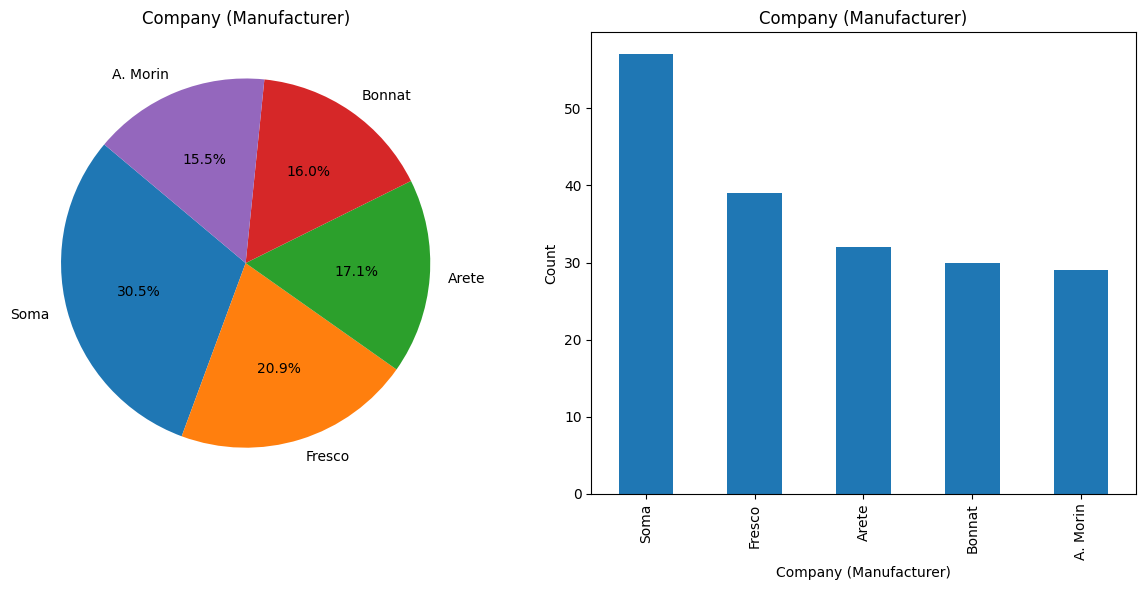

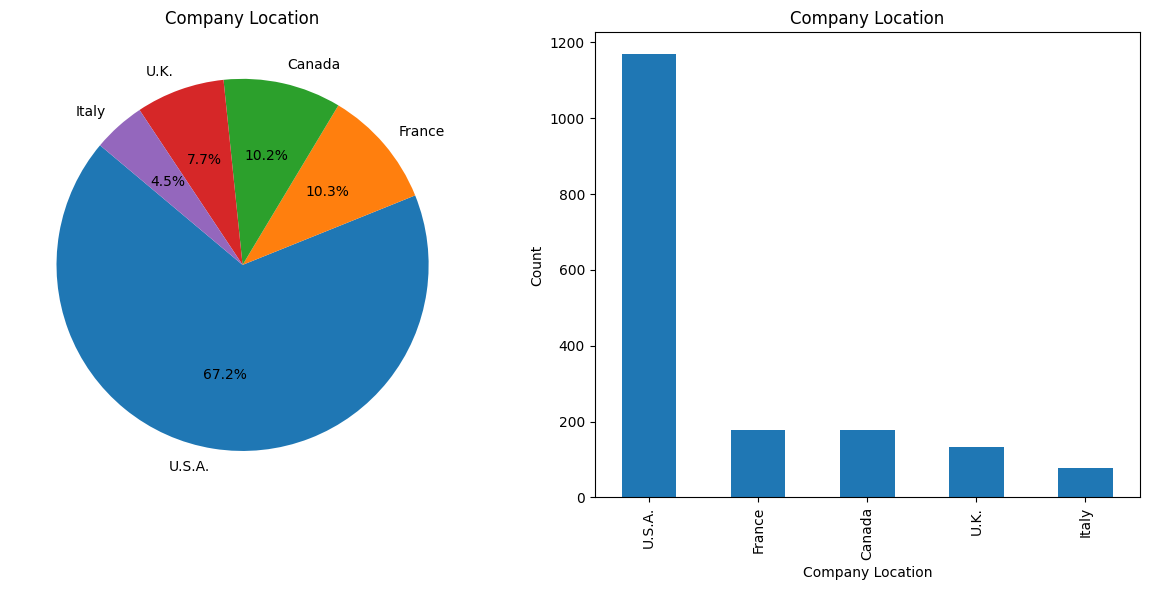

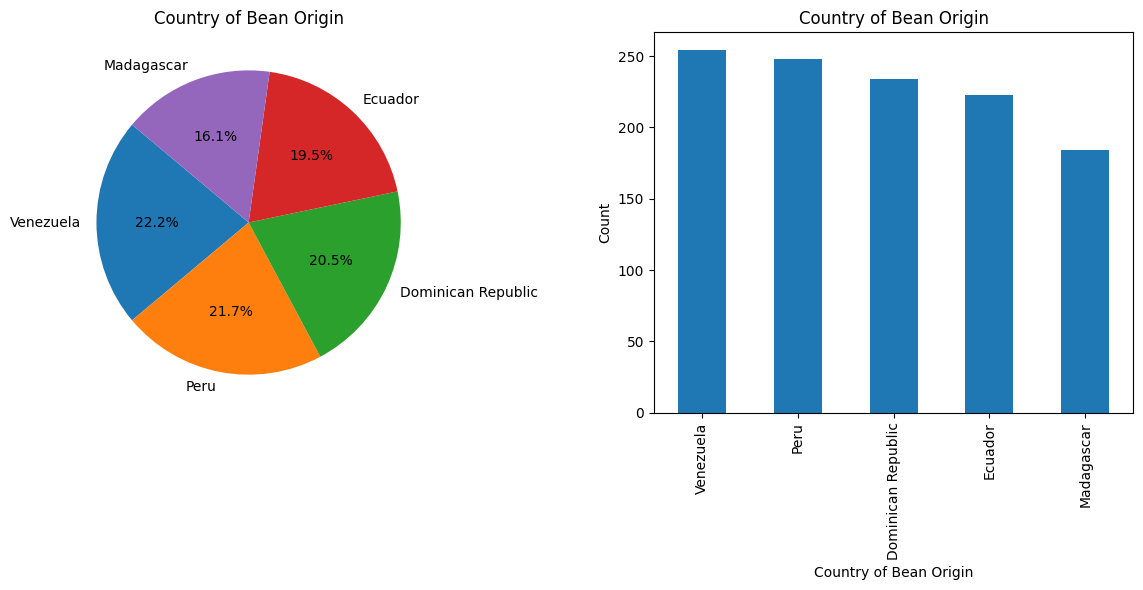

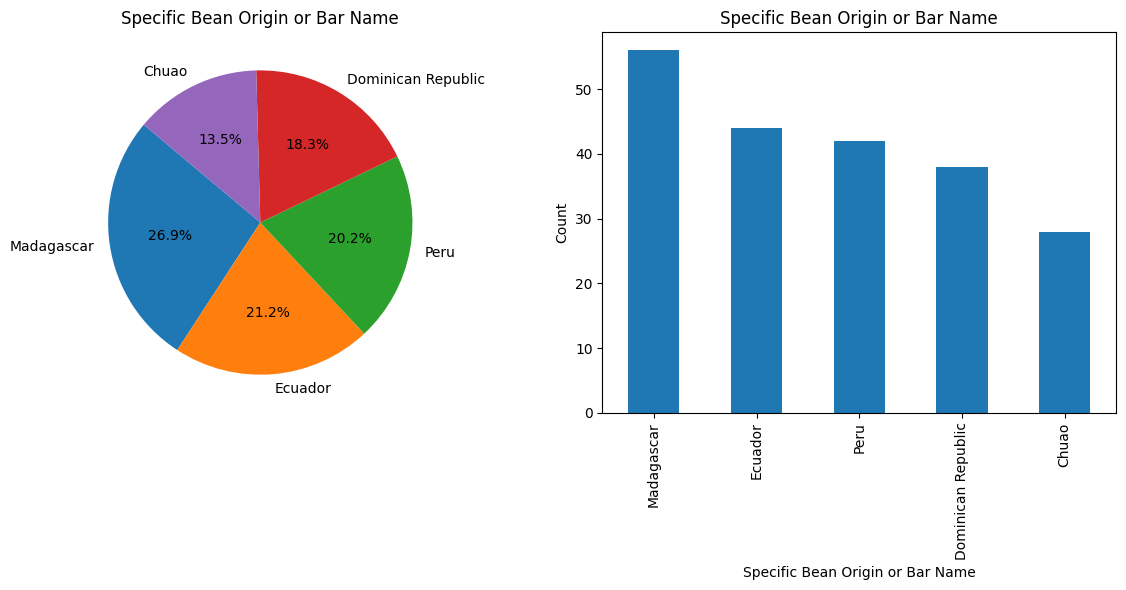

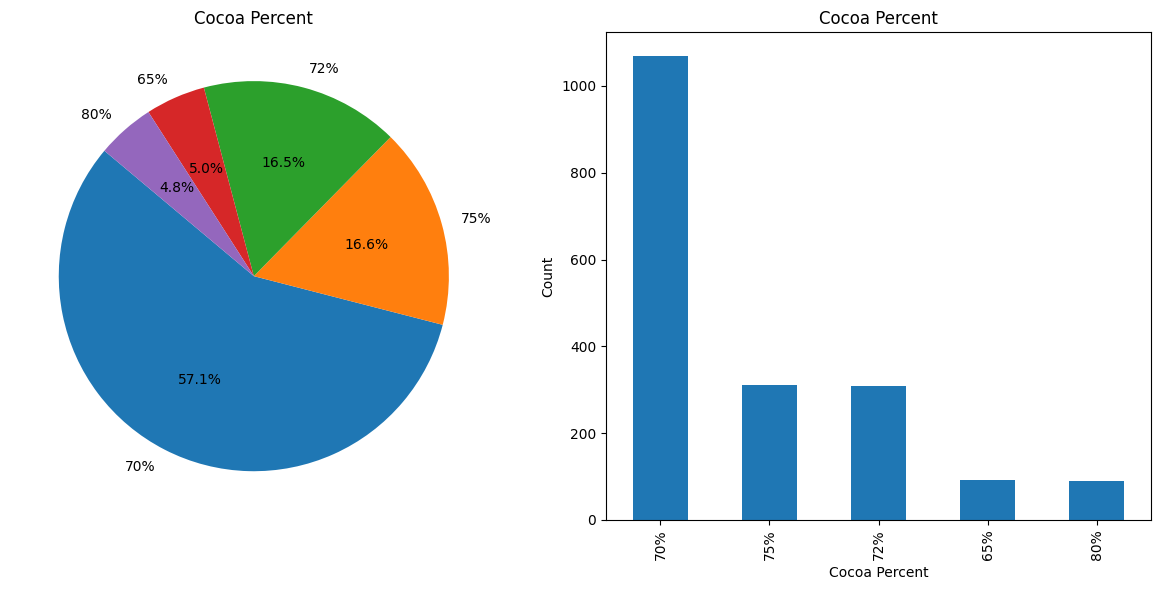

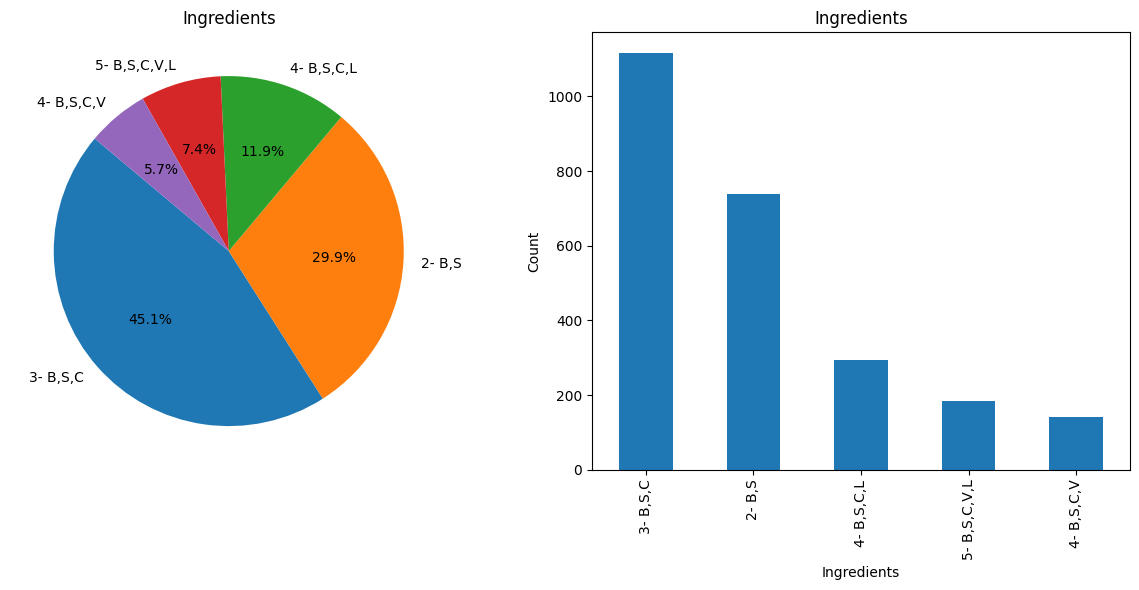

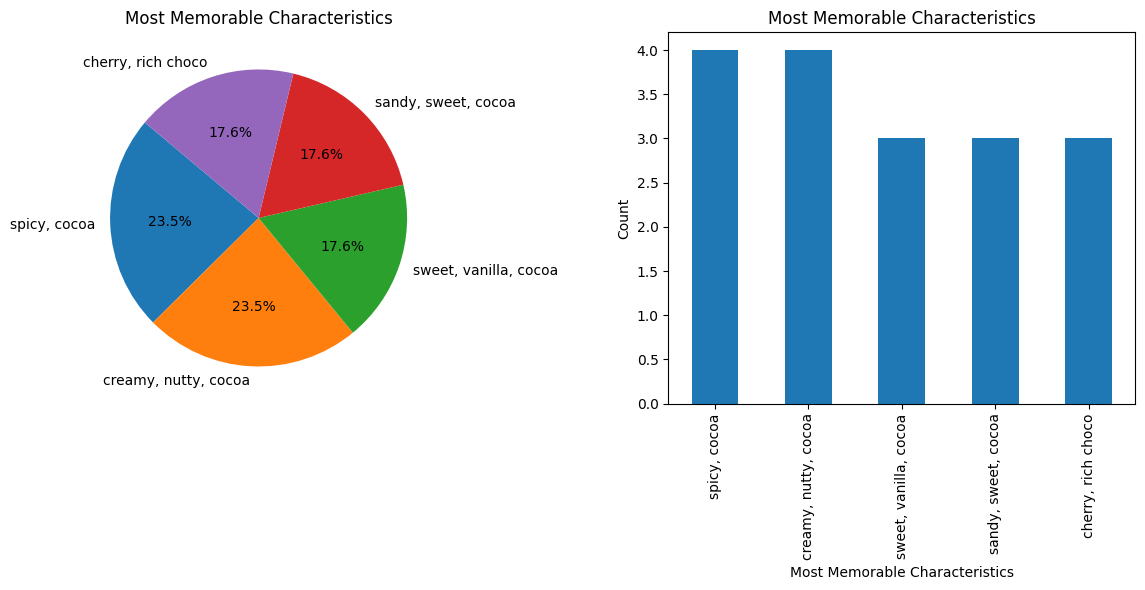

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = df.select_dtypes(include=['object'])

for i in categorical_features.columns:
  counts = categorical_features[i].value_counts().head(5) # Show only top 10
  # Plotting
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))
  # Pie chart
  axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
  axes[0].set_title(i)
  # Bar chart
  counts.plot(kind='bar', ax=axes[1])
  axes[1].set_title(i)
  axes[1].set_ylabel('Count')
  axes[1].set_xlabel(i)
  plt.tight_layout()
  plt.show()


In [ ]:
# prompt: apply this code on my data
# import plotly.express as px
# df = px.data.gapminder()
# fig = px.scatter_geo(df, locations="iso_alpha", color="continent", hover_name="country", size="pop",
#                animation_frame="year", projection="natural earth")
# fig.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('/content/Chocolate bar ratings 2022.csv')

# ... (Your existing data cleaning and preprocessing code)

# Assuming you want to create a scatter map based on 'Company Location'
# and color it by 'Rating'
# You will need to find the latitude and longitude of each 'Company Location'
# If you have that data available in your dataframe you can plot it

# If you have latitude and longitude data in your dataframe
# Replace 'latitude' and 'longitude' with your actual column names
if 'latitude' in df.columns and 'longitude' in df.columns:
  fig = px.scatter_map(df, lat="latitude", lon="longitude", color="Rating",
                      size="Cocoa Percent", # You can change this to another suitable size variable
                      color_continuous_scale=px.colors.cyclical.IceFire,
                      size_max=15, zoom=2,
                      map_style="carto-positron")
  fig.show()
else:
  print("Latitude and longitude data not found in DataFrame. Please add it to create the map.")


# Example of a scatter plot with Rating on the y-axis and Cocoa Percent on the x-axis
fig = px.scatter(df, x="Cocoa Percent", y="Rating", color="Company Location",
                 size="Rating", hover_data=['Specific Bean Origin or Bar Name'])
fig.show()

# Example of a bar chart showing the count of chocolate bars by country of bean origin
fig = px.histogram(df, x="Country of Bean Origin")
fig.show()

# Example of a box plot showing the distribution of ratings by company location
fig = px.box(df, x="Company Location", y="Rating")
fig.show()

# Example of a choropleth map using plotly express
df_company_counts = df.groupby('Company Location')['Rating'].count().reset_index()
fig = px.choropleth(df_company_counts, locations="Company Location",
                    locationmode="country names", color="Rating",
                    hover_name="Company Location",
                    title="Number of Chocolate Bars by Company Location")
fig.show()

# Example of an animated scatter plot using plotly express
df_year = df.copy()  # Assuming you have a 'year' column
# If you don't have a year column you can create a year column based on review date
# df_year['Year'] = pd.to_datetime(df_year['Review Date']).dt.year
fig = px.scatter(df_year, x="Cocoa Percent", y="Rating", animation_frame="Review Date",
                 animation_group="Company Location", size="Rating", color="Company Location",
                 hover_name="Company Location")
fig.show()

# ... You can add more visualization code as needed


Latitude and longitude data not found in DataFrame. Please add it to create the map.


In [ ]:
df['Ingredients'].value_counts()

,count
Ingredients,
"3- B,S,C",1029
"2- B,S",738
"4- B,S,C,L",293
"5- B,S,C,V,L",184
"4- B,S,C,V",141
"2- B,S*",31
"4- B,S*,C,Sa",20
"3- B,S*,C",13
"3- B,S,L",8


In [ ]:
df['Rating'].value_counts()

,count
Rating,
3.50,584
3.00,534
3.25,474
2.75,339
3.75,306
2.50,169
4.00,115
2.00,33
2.25,17


In [ ]:
mean_values = df.groupby('Ingredients')["Rating"].mean()
print(mean_values)

Ingredients
1- B              2.958333
2- B,C            3.000000
2- B,S            3.231030
2- B,S*           2.959677
3- B,S*,C         2.980769
3- B,S*,Sa        2.500000
3- B,S,C          3.278669
3- B,S,L          2.687500
3- B,S,V          3.166667
4- B,S*,C,L       2.875000
4- B,S*,C,Sa      3.112500
4- B,S*,C,V       3.000000
4- B,S*,V,L       3.083333
4- B,S,C,L        3.214164
4- B,S,C,Sa       3.150000
4- B,S,C,V        2.975177
4- B,S,V,L        2.900000
5- B,S,C,L,Sa     3.000000
5- B,S,C,V,L      3.089674
5-B,S,C,V,Sa      2.791667
6-B,S,C,V,L,Sa    2.937500
Name: Rating, dtype: float64


In [ ]:
df.head()

,REF,Company (Manufacturer),Company Location,Review Date,Country of Bean Origin,Specific Bean Origin or Bar Name,Cocoa Percent,Ingredients,Most Memorable Characteristics,Rating
0,2454,5150,U.S.A.,2019,Tanzania,"Kokoa Kamili, batch 1",76%,"3- B,S,C","rich cocoa, fatty, bready",3.25
1,2454,5150,U.S.A.,2019,Madagascar,"Bejofo Estate, batch 1",76%,"3- B,S,C","cocoa, blackberry, full body",3.75
2,2458,5150,U.S.A.,2019,Dominican Republic,"Zorzal, batch 1",76%,"3- B,S,C","cocoa, vegetal, savory",3.50
3,2542,5150,U.S.A.,2021,Fiji,"Matasawalevu, batch 1",68%,"3- B,S,C","chewy, off, rubbery",3.00
4,2542,5150,U.S.A.,2021,India,"Anamalai, batch 1",68%,"3- B,S,C","milk brownie, macadamia,chewy",3.50


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df_encoded = pd.get_dummies(df, columns=["Company Location", "Country of Bean Origin", "Specific Bean Origin or Bar Name", "Ingredients", "Most Memorable Characteristics"])
df_encoded.head()


,REF,Company (Manufacturer),Review Date,Cocoa Percent,Rating,Company Location_Argentina,Company Location_Australia,Company Location_Austria,Company Location_Belgium,Company Location_Bolivia,...,"Most Memorable Characteristics_woody, mocha, molasses","Most Memorable Characteristics_woody, nutty, off sour note","Most Memorable Characteristics_woody, nutty, short","Most Memorable Characteristics_woody, red berry, sour","Most Memorable Characteristics_woody, red fruit, sour","Most Memorable Characteristics_woody, spicy, tobacco","Most Memorable Characteristics_woody, sweet, unrefined","Most Memorable Characteristics_woody, toast, pepper",Most Memorable Characteristics_yellow fruit,"Most Memorable Characteristics_yogurt, lemon, licorice"
0,2454,5150,2019,76%,3.25,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2454,5150,2019,76%,3.75,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2458,5150,2019,76%,3.50,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2542,5150,2021,68%,3.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2542,5150,2021,68%,3.50,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Assuming 'df_encoded' is your DataFrame with the 'furnishingstatus' column.
# Replace 'df_encoded' with your actual DataFrame name if different.

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'furnishingstatus' column
if 'Company Location' in df_encoded.columns:
  df_encoded['Company Location'] = label_encoder.fit_transform(df_encoded['Company Location'])

# Display the first few rows of the encoded DataFrame
df_encoded.head(25)


,REF,Company (Manufacturer),Review Date,Cocoa Percent,Rating,Company Location_Argentina,Company Location_Australia,Company Location_Austria,Company Location_Belgium,Company Location_Bolivia,...,"Most Memorable Characteristics_woody, mocha, molasses","Most Memorable Characteristics_woody, nutty, off sour note","Most Memorable Characteristics_woody, nutty, short","Most Memorable Characteristics_woody, red berry, sour","Most Memorable Characteristics_woody, red fruit, sour","Most Memorable Characteristics_woody, spicy, tobacco","Most Memorable Characteristics_woody, sweet, unrefined","Most Memorable Characteristics_woody, toast, pepper",Most Memorable Characteristics_yellow fruit,"Most Memorable Characteristics_yogurt, lemon, licorice"
0,2454,5150,2019,76%,3.25,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2454,5150,2019,76%,3.75,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2458,5150,2019,76%,3.50,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2542,5150,2021,68%,3.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2542,5150,2021,68%,3.50,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,2546,5150,2021,72%,3.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,2546,5150,2021,80%,3.25,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,797,A. Morin,2012,70%,3.50,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,797,A. Morin,2012,63%,3.75,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,1011,A. Morin,2013,70%,2.75,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
